## All the President's Speeches 

As we learned on Friday, word frequency distribution is an intuitive way of determining the major themes, topics, or even preoccupations of the speech giver. Pull texts from different US presidents and use FreqDist() to gain insights into the data. This is a fairly open assignment. The goal is to identify something interesting! Pull the text, tokenize, remove stopwords, and plot the frequency of the words. That's the technical part. But much of this assignment is your ability to use word frequency to gain insights comparatively, intra or inter presidents. Let the python notebook from our lecture be your guide! The more interesting and creative the analysis, the more points you will receive. We might pick one student's analysis to be displayed in lecture, and that person will receive bonus credit for the work.

In [ ]:
1. #Your code here:
import nltk
nltk.download()


## Words to Vectors
The word-count model is useful because it is simple, transparent, and easy to teach. But it is a very crude sensor. A vector-similarity framing gets much closer to what you likely actually care about:

not whether the exact token “liberty” appears,
but whether the speech is semantically near the concept of liberty.

That is a much better statement of the problem.

Why vector similarity may be better

A count-based model assumes:

idea ≈ exact word
meaning is stable over time
synonyms do not matter much
rhetoric is directly observable through lexical frequency

Those assumptions are weak.

A vector approach instead says:

each sentence, paragraph, or speech can be embedded as a vector
the concept “liberty” can also be represented as a vector
ideological signal is proximity in semantic space

What the vector version changes

With vector similarity, your observation is no longer a count. It becomes a continuous score.
​


A president can talk at length about liberty without ever saying “liberty.”

Your count model misses that entirely.

But there are real problems

This is where the vector story gets more serious.

1. Embeddings are not historically neutral

A modern embedding model may not represent 1790 or 1860 language properly.

“Liberty” in 1801, “freedom” in 1865, and “democracy” in 2009 may cluster differently depending on the model and training corpus.

So vector similarity can quietly import present-day semantics into historical text.

That is a major issue.

2. Concept vectors are slippery

What exactly is the vector for “liberty”?

Is it:

the embedding of the single word “liberty”?
the average embedding of a hand-built definition?
the centroid of example passages?
a contrastive dimension versus “authority” or “order”?

That choice matters a lot.

3. Similarity is not the same as endorsement

A speech may be semantically close to liberty because it is criticizing it, qualifying it, or subordinating it.

Similarity detects topical proximity, not stance.

4. Interpretability drops

“Count of liberty per 1,000 words” is easy to explain.

“Average cosine similarity between sentence embeddings and a constructed liberty centroid” is much harder to defend to a skeptical audience.

the neural network learns to associate words that appear in similar contexts with similar vector representations in the vector space.

Word2vec is a popular machine learning algorithm for generating word embeddings, which are numerical representations of words in a high-dimensional vector space. The algorithm was developed by Google researchers Tomas Mikolov, Kai Chen, Greg Corrado, and Jeffrey Dean in 2013.

The main idea behind word2vec is to use a neural network to learn the vector representations of words based on the context in which they appear in a large corpus of text. The algorithm has two different architectures: continuous bag-of-words (CBOW) and skip-gram.

In the CBOW architecture, the algorithm tries to predict the current word based on a window of surrounding words. In the skip-gram architecture, the algorithm tries to predict the surrounding words based on the current word. In both cases, the neural network learns to associate words that appear in similar contexts with similar vector representations in the vector space.

The resulting word embeddings can be used in a variety of natural language processing (NLP) tasks, such as text classification, sentiment analysis, and machine translation. One of the key benefits of word embeddings is that they can capture semantic relationships between words, such as synonyms, antonyms, and analogies. For example, in the vector space learned by word2vec, the vector for "king" might be close to the vector for "queen", and the vector for "man" might be close to the vector for "woman".



Word2vec helps us understand how words are related to each other. You can think of it like a game where you try to guess which words are often used together.

For example, imagine you're reading a story about a cat who goes on an adventure. The words "cat" and "adventure" often appear together in the story. Word2vec learns from these patterns and puts the words "cat" and "adventure" closer together in a big list of all the words in the story.

Word2vec can also help us understand how words are related in other ways. For instance, it can figure out that "king" and "queen" are related words, just like "man" and "woman". It does this by looking at how often these words appear together in lots of different texts.

So, word2vec helps us understand how words are related and can help us make predictions about which words might appear together in a sentence or paragraph. This is useful in many different areas, like understanding how people talk about products in reviews or how people talk about politics on social media.

Watch this video:
https://www.youtube.com/watch?v=iErmK_sJtag


In [14]:
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from string import punctuation 
from nltk.corpus import gutenberg
from pprint import pprint

In [ ]:
bible_sents = gutenberg.sents('bible-kjv.txt')
sw = stopwords.words('english')
bible = [[w.lower() for w in s if w not in punctuation and w not in sw] for s in bible_sents]
print(len(bible))



bible_vec = Word2Vec(bible)
pprint(bible_vec.wv.most_similar('god', topn=8))

In [ ]:
pprint(bible_vec.wv.most_similar('devil', topn=8))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the two paragraphs
paragraph1 = """
Bees are flying insects closely related to wasps and ants, known for their role in pollination and, in the case of the best-known bee species, the western honey bee, for producing honey. Bees are a monophyletic lineage within the superfamily Apoidea. They are presently considered a clade, called Anthophila. There are over 16,000 known species of bees in seven recognized biological families. Some species – including honey bees, bumblebees, and stingless bees – are solitary, but most bees are social insects, forming colonies that contain many individuals. The most common type of bee found in homes is the honey bee, but there are over 4,000 different species of bees. Other types of bees include carpenter bees, which burrow into wood to lay their eggs, and mining bees, which live underground. Bees range in size from tiny stingless bee species whose workers are less than 2 millimeters (0.08 in) long, to Megachile pluto, the largest species of leafcutter bee, whose females can attain a length of 39 millimeters (1.54 in). The most common bees in the Northern Hemisphere are the Halictidae, or sweat bees, but they are small and often mistaken for wasps or flies.
"""

paragraph2 = "According to all known laws of aviation, there is no way a bee should be able to fly."
# Preprocess the text data
# You may need additional preprocessing steps depending on your data
# For now, we'll keep it simple by converting all text to lowercase
paragraph1 = paragraph1.lower()
paragraph2 = paragraph2.lower()

# Vectorize the text using CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([paragraph1, paragraph2])

# Compute the similarity between the vectors
similarity_score = cosine_similarity(X)
print("Similarity Score between the two paragraphs:", similarity_score[0,1])


## Sentiment Analysis
What is sentiment analysis? Sentiment analysis is a process of using natural language processing, machine learning, and computational linguistics to analyze the attitudes, opinions, and emotions expressed in text data. The goal of sentiment analysis is to determine the sentiment, or emotional tone, of a piece of text, which can be positive, negative, or neutral. Sentiment analysis can be applied to a wide range of text data, including social media posts, product reviews, news articles, and customer feedback. The results of sentiment analysis can be used to gain insights into customer satisfaction, brand reputation, and public opinion on various topics.




In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()


Working and Scoring
Let's test our first sentiment using VADER now. We will use the polarity_scores( ) method to obtain the polatiry indices for the given sentence:

In [ ]:
sentence = "I love that movie!"
score = analyzer.polarity_scores(sentence)
print(score)

In [ ]:
sentence2 = "OMG, I freaked out when I saw it!"
score = analyzer.polarity_scores(sentence2)
print(score)


In [ ]:
sentence3 = "That rocks!"
score = analyzer.polarity_scores(sentence3)
print(score)

In [ ]:
sentence4 = '🫂' #command+control+space brings up emoji'
score = analyzer.polarity_scores(sentence4)
print(score)

In [ ]:
sentence5 = ' 😒' #command+control+space brings up emoji'
score = analyzer.polarity_scores(sentence5)
print(score)

In [ ]:
sentence6 = '😭'
score = analyzer.polarity_scores(sentence6)
print(score)

In [ ]:
sentence7 = 'That movie was 💩'
score = analyzer.polarity_scores(sentence6)
print(score)

In [ ]:
from nltk.corpus import inaugural

print(inaugural.fileids())

In [ ]:
!pip install textblob
from textblob import TextBlob

# Define the text passage to analyze
text = inaugural.raw('1865-Lincoln.txt')
# Perform tone analysis on the text passage
blob = TextBlob(sentence7)
polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity



# Print the tone analysis results
if polarity > 0:
    print("The text is more positive than negative.")
elif polarity < 0:
    print("The text is more negative than positive.")
else:
    print("The text is neutral.")
    
if subjectivity > 0.5:
    print("The text is more subjective than objective.")
else:
    print("The text is more objective than subjective.")

2. How is text blob different than Vader? When would I use Text Blob? When Vader?
3. 
Your answer here: Text blob offers the ability to assess how subjective a text file is, compared to just how positive/negative/nuetral the tone of the text is. However, when running textblob on sentence7 (with an emoji), it labels the sentence as nuetral, rather than negative - which is the correct categorization. Perhaps textblob is better for formal texts while vader is preferable for more informal versions of text, and samples that would not benefit from objective/subjective rating analysis.



In [ ]:
3. Create a hypothesis about the presidential inaugural speeches and use entiment analysis to test your hypothesis.

In [15]:
#Your code and answer here:
# I hypothesize that in inaugural speeches following the 'alignment' modern political affiliations (Democrats as liberals and Republicans
# as conservatives in ~ 1975 that democratic innagural speeches will mention the concept of 'future' more.

import numpy as np
from nltk.corpus import inaugural


# dem_speeches_post1975 = inaugural.raw(['1977-Carter.txt','1993-Clinton.txt', '1997-Clinton.txt', '2009-Obama.txt', '2013-Obama.txt', '2021-Biden.txt'])
# rep_speeches_post1975 = inaugural.raw(['1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '2001-Bush.txt', '2005-Bush.txt', '2017-Trump.txt', '2025-Trump.txt'])

dem_files = ['1977-Carter.txt','1993-Clinton.txt', '1997-Clinton.txt', '2009-Obama.txt', '2013-Obama.txt', '2021-Biden.txt']
rep_files = ['1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '2001-Bush.txt', '2005-Bush.txt', '2017-Trump.txt', '2025-Trump.txt']

sw = stopwords.words('english')

def process_speeches(file_list):
    all_sents = [] # list for all sentences
    for file in file_list:
        sents = inaugural.sents(file) # loop to access each speech file in the list, broken down to sentences - add to variable called sents
        cleaned = [[w.lower() for w in s if w.lower() not in punctuation and w.lower() not in sw]
                   for s in sents] #  for words in each sentence that are not punctuation or in sw, convert to lower case and add to variable called cleaned
        all_sents.extend(cleaned) # Add contents of 'cleaned' into all_sents
    return all_sents

dem_sents = process_speeches(dem_files) # Define democratic sentences to put into the model
rep_sents = process_speeches(rep_files)

dem_vec = Word2Vec(dem_sents, vector_size=100, window=5, min_count=1, workers=4) 
rep_vec = Word2Vec(rep_sents, vector_size=100, window=5, min_count=1, workers=4)


progressive_words = ['change', 'progress', 'reform', 'innovation', 'tomorrow',
    'future', 'forward', 'new', 'transformation', 'growth',
    'opportunity', 'potential', 'advancement']
traditional_words = ['tradition', 'heritage', 'values', 'founding', 'constitution',
    'liberty', 'faith', 'principles', 'foundation', 'history',
    'legacy', 'honor', 'duty']

def avg_similarity(model, target_word, word_list):
    similarities = []
    for word in word_list:
        try:
            sim = model.wv.similarity(target_word, word)
            similarities.append(sim)
        except KeyError:
            pass
        return np.mean(similarities) if similarities else 0


print(f"Democrats: {avg_similarity(dem_vec, 'future', progressive_words):.4f}")
print(f"Republicans: {avg_similarity(rep_vec, 'future', progressive_words):.4f}")


print(f"Democrats: {avg_similarity(dem_vec, 'future', traditional_words):.4f}")
print(f"Republicans: {avg_similarity(rep_vec, 'future', traditional_words):.4f}")

    

Democrats: 0.1122
Republicans: 0.0852
Democrats: 0.0000
Republicans: -0.2288


## Reading a file and writing to a file



In [ ]:
with open("example.txt", "w") as file:
    file.write("This is the first line of the file.\n")
    file.write("This is the second line of the file.\n")

In this example, we use the with open statement to open the file "example.txt" in write mode ("w") and assign it to the variable file. Then, we use the write() method to write two lines of text to the file. Since we're using the with statement, we don't need to manually close the file; Python will do it for us when the block of code inside the with statement is done executing.



Reading a file: In this example, we open a file called "example.txt" in read mode and read the entire contents of the file into a variable called content. 

In [ ]:
#Using the with open statement is a cleaner and safer way to open and read a file in Python, as it automatically closes the file for you when you're done with it, even if an error occurs. Here's an example:

with open("example.txt", "r") as file:
    content = file.read()
    print(content)

In [ ]:
with open("example.txt", "r") as file:
    content = file.readlines()
    print(content)

What is the difference between the read and readlines methods?

Your answer here: The readlines file reads the string as it was entered, showing how it was coded upon entry. The simple read function displays the clean output (without quotation mark and \n aspects).

## Intro to Scraping

Text scraping, also known as web scraping or data scraping, refers to the process of automatically extracting text data from websites or other online sources.

Below is some code for you to scrape a website. The package is called "Beautiful Soup" I have given you code below to use. 

I have given you TWO websites to scrape. PLEASE PICK ONE of TWO.
Either:

1. A speech from Christine LaGrande on Sustainable Development Goals
https://www.imf.org/en/News/Articles/2018/09/17/sp09172018-the-case-for-the-sustainable-development-goals'
OR
2. "Joint Statement of the Russian Federation and the People’s Republic of China on the International Relations Entering a New Era and the Global Sustainable Development" Feb, 2022
http://www.en.kremlin.ru/supplement/5770


In [ ]:
!pip install beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup
 
base_url = "http://www.en.kremlin.ru/supplement/5770" #use one the urls above as a string
r = requests.get(base_url)
soup = BeautifulSoup(r.text)
paragraphs = soup.find_all('p')

for p in paragraphs:
    print(p.get_text())

In [ ]:
4. Modify the text above to write the text to a list called "document"

In [8]:
#Your code here: 
import requests
from bs4 import BeautifulSoup
import re

base_url = "https://www.imf.org/en/News/Articles/2018/09/17/sp09172018-the-case-for-the-sustainable-development-goals"
r = requests.get(base_url)
soup = BeautifulSoup(r.text, "html.parser")
paragraphs = soup.find_all("p")

document = []  

for p in paragraphs:
    words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", p.get_text().lower())
    document.extend(words)


5. Clean the document of any extraneous elements, remove stopwords and perform a word frequency distribution analysis on your document, showing and then plotting the top 20 words

[('sdgs', 20), ('countries', 19), ('helen', 18), ('world', 14), ('economic', 14), ('imf', 13), ('percent', 13), ('inequality', 12), ('income', 11), ('women', 10), ('need', 10), ('global', 10), ('sdg', 10), ('dimension', 10), ('one', 9), ('social', 9), ('education', 9), ('corruption', 9), ('let', 8), ('also', 8)]
Axes(0.125,0.11;0.775x0.77)


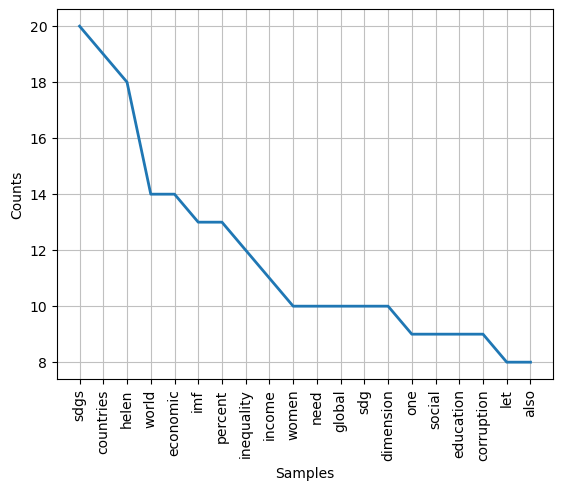

In [9]:
# Your code here:
import nltk
from nltk.corpus import stopwords
from nltk import FreqDist

clean_document = []
stopwords = nltk.corpus.stopwords.words("english")
for word in document:
    if not word.lower() in stopwords:
        clean_document.append(word)
        
fdist = FreqDist(clean_document)
print(fdist.most_common(20))
print(fdist.plot(20))

Please read the speech. What does the word frequency tell us, if anything, about the speech? Please answer in a short paragraph that tells me how the word frequency distribution is good at finding meaning, but also may miss the meaning that you gained from actually reading the article. 

6. ### Your paragraph here: 


The word frequency distribution does a good job of providing us with basic context of the text, such as the primary topic of SDGs and the scale at which they are being discussed (international, worldwide), and even the precense of a 'helen' character who is being mentioned often. However, this is really the extent of the information that frequency distribution provides as it relates to the meaning of the speech. The distribution cannot tell us that 'helen' appears a lot because it is a speech in her honor. It cannot tell us content from the sdgs, but it can provide insight as to what some of the topics might be (education, corruption, women). It also has no way (in this current form) to indicate which of these words/topics are related. For example, from this frequency distribution one might assume that the education of women, or the income of women is a specific goal of the sdg. However, in the speech, women are only mentioned in the context of income, and not in the context of education. This is a nuance that cannot be discerned from the frequency distribution. 


## Other language analysis:

Here is a link to a github repo that contains Donald Trump's speeches: https://github.com/ryanmcdermott/trump-speeches/blob/master/speeches.txt
What are the 10 most common things Donald Trump "loves?"

In [10]:
7. #Your code and answer here:

import requests, re

url = "https://raw.githubusercontent.com/ryanmcdermott/trump-speeches/master/speeches.txt"
text = requests.get(url).text

# splits into sentences
sents = re.split(r"[.!?]\s+", text)

sw = set(stopwords.words("english"))
corpus = []
for s in sents:
    words = s.lower().split()
    words = [w for w in words if w not in sw and w not in punctuation]
    if words:
        corpus.append(words)

model = Word2Vec(corpus, vector_size=100, window=5, min_count=3, workers=4)


pprint(model.wv.most_similar("love", topn=10))

[('left', 0.999531626701355),
 ('totally', 0.9994882345199585),
 ('place', 0.9994811415672302),
 ('trump', 0.9994600415229797),
 ('wanted', 0.9994509816169739),
 ('people,', 0.9994434118270874),
 ('anybody', 0.9994342923164368),
 ('mean', 0.9994328618049622),
 ('american', 0.9994292855262756),
 ('that,', 0.9994291663169861)]


Which are the top 5 countries Trump mentions in his speeches, besides America or the United States of America?


In [12]:
8. #Your code and answer here:
from collections import Counter

url = "https://raw.githubusercontent.com/ryanmcdermott/trump-speeches/master/speeches.txt"
text = requests.get(url).text

countries = ["Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria", "Burkina Faso", "Burundi", "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros", "Congo, Democratic Republic of the", "Congo, Republic of the", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czechia", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Korea, North", "Korea, South", "Kosovo", "Kuwait", "Kyrgyzstan", "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein", "Lithuania", "Luxembourg", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania", "Mauritius", "Mexico", "Micronesia", "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Macedonia", "Norway", "Oman", "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland", "Portugal", "Qatar", "Romania", "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines", "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal", "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "Somalia", "South Africa", "South Sudan", "Spain", "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria", "Taiwan", "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga", "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", "United States", "Uruguay", "Uzbekistan", "Vanuatu", "Vatican City", "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"]

counts = Counter()
for c in countries:
    counts[c] = len(re.findall(rf"\b{re.escape(c)}\b", text))

print(counts.most_common(5))

[('China', 200), ('Mexico', 156), ('United States', 116), ('Iran', 89), ('Israel', 83)]
